# GDS(Graph Data Science)를 활용한 영화 추천 시스템

이 노트북에서는 Neo4j의 GDS 라이브러리를 활용하여 영화 추천 시스템을 구축합니다.



## 학습 목표
1. GDS 라이브러리의 기본 사용법 이해
2. 그래프 프로젝션(Graph Projection) 방법 학습
3. PageRank 알고리즘으로 인기 영화 찾기
4. Node Similarity로 유사 영화 추천
5. Community Detection으로 영화 그룹 분석
6. 실제 추천 시스템 구현


## 1. GDS란?

GDS(Graph Data Science)는 Neo4j에서 제공하는 그래프 데이터 과학 라이브러리입니다.

### 주요 특징
- **그래프 알고리즘**: PageRank, Centrality, Community Detection 등
- **그래프 임베딩**: 노드를 벡터로 변환하여 ML 모델에 활용
- **성능 최적화**: 대규모 그래프 데이터를 효율적으로 처리
- **Python 통합**: `graphdatascience` 라이브러리를 통해 쉽게 사용

### 추천 시스템에서의 활용
- **PageRank**: 인기 있는 영화/사용자 찾기
- **Node Similarity**: 유사한 영화/사용자 찾기
- **Community Detection**: 비슷한 취향의 사용자 그룹 찾기


## 2. 필요한 라이브러리 설치 및 import


In [64]:
import pandas as pd
import ast
from neo4j import GraphDatabase
from graphdatascience import GraphDataScience

# 경고 메시지 숨기기 (선택사항)
import warnings
warnings.filterwarnings('ignore')


## 3. Neo4j 연결 설정


In [65]:
# ============================================
# Neo4j 연결 정보 설정
# ============================================
URI = "bolt://localhost:7687"
USERNAME = "neo4j"
PASSWORD = "test1234"

### Neo4j 드라이버 생성

In [66]:
# ============================================
# Neo4j 드라이버 생성
# ============================================
driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

### GDS 객체 생성

In [67]:
# ============================================
# GDS 객체 생성
# ============================================
# GraphDataScience: GDS 라이브러리의 메인 클래스
# driver: Neo4j 드라이버 객체를 전달
gds = GraphDataScience(URI, auth=(USERNAME, PASSWORD))

In [68]:
# 연결 테스트
try:
    result = driver.session().run("RETURN 1 as test")
    print("Neo4j 연결 성공!")
except Exception as e:
    print(f"Neo4j 연결 실패: {e}")


Neo4j 연결 성공!


## 4. 데이터 로딩 및 전처리

영화 데이터셋을 로드하고 Neo4j에 적합한 형태로 전처리합니다.


### 영화 메타데이터 로드

In [69]:
# 영화 메타데이터 로드
movies_df = pd.read_csv('data/movies_metadata.csv', low_memory=False)
print(f"영화 데이터: {len(movies_df)}개")


영화 데이터: 45466개


### 평점 데이터 로드

In [70]:
# 평점 데이터 로드
ratings_df = pd.read_csv('data/ratings_small.csv')
print(f"평점 데이터: {len(ratings_df)}개")


평점 데이터: 100004개


In [71]:
# 데이터 샘플링 (실습 속도를 위해)
# 전체 데이터를 사용하려면 이 부분을 주석 처리하세요
SAMPLE_SIZE = 5000  # 영화 수 제한
if len(movies_df) > SAMPLE_SIZE:
    movies_df = movies_df.head(SAMPLE_SIZE)
    movie_ids = set(movies_df['id'].astype(str))
    ratings_df = ratings_df[ratings_df['movieId'].astype(str).isin(movie_ids)]
    print(f"샘플링 후 - 영화: {len(movies_df)}개, 평점: {len(ratings_df)}개")

print("\n데이터 로딩 완료!")

샘플링 후 - 영화: 5000개, 평점: 19269개

데이터 로딩 완료!


### 데이터 전처리

In [72]:
# ============================================
# 데이터 전처리: 장르 파싱
# ============================================
def parse_genres(genres_str):
    """
    장르 문자열을 파싱하여 장르 이름 리스트 반환
    
    예: "[{'id': 16, 'name': 'Animation'}, ...]" 
    -> ['Animation', 'Comedy', ...]
    """
    if pd.isna(genres_str) or genres_str == '':
        return []
    
    try:
        # 문자열을 딕셔너리 리스트로 변환
        genres_list = ast.literal_eval(genres_str)
        # 장르 이름만 추출
        return [g['name'] for g in genres_list if isinstance(g, dict) and 'name' in g]
    except:
        return []
        

In [73]:
# 영화 데이터에 장르 리스트 추가
movies_df['genres_list'] = movies_df['genres'].apply(parse_genres)
print("장르 파싱 완료!")


장르 파싱 완료!


In [74]:
# 샘플 확인
print("\n샘플 영화 데이터:")
sample_movie = movies_df[['title', 'genres_list']].head(3)
for idx, row in sample_movie.iterrows():
    print(f"  - {row['title']}: {row['genres_list']}")



샘플 영화 데이터:
  - Toy Story: ['Animation', 'Comedy', 'Family']
  - Jumanji: ['Adventure', 'Fantasy', 'Family']
  - Grumpier Old Men: ['Romance', 'Comedy']


## 5. Neo4j 그래프 생성

영화, 사용자, 장르를 노드로, 평점과 장르 관계를 엣지로 생성합니다.


### 기존 데이터 삭제

In [75]:
# ============================================
# 기존 데이터 삭제 (선택사항)
# ============================================
# 주의: 모든 데이터가 삭제됩니다!
def clear_database():
    """Neo4j의 모든 노드와 관계를 삭제"""
    with driver.session() as session:
        # MATCH (n): 모든 노드 선택
        # DETACH DELETE n: 노드와 연결된 모든 관계를 먼저 삭제한 후 노드 삭제
        # (DETACH 없이 DELETE하면 관계가 있는 노드는 삭제 불가)
        session.run("MATCH (n) DETACH DELETE n")
    print("기존 데이터 삭제 완료!")
    

In [76]:
clear_database()


기존 데이터 삭제 완료!


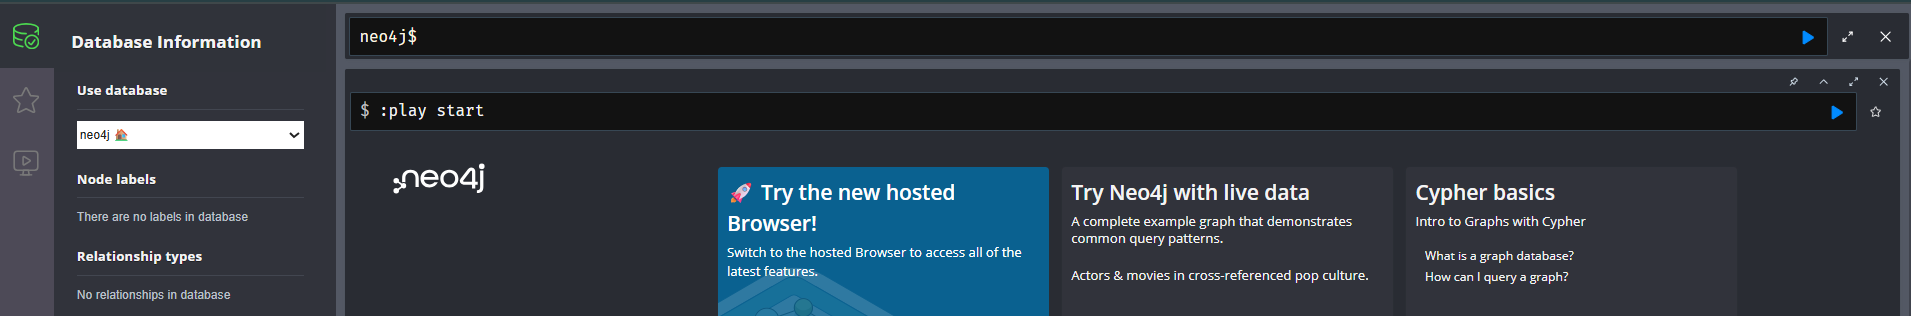

### 영화 노드 생성

In [77]:
# ============================================
# 영화 노드 생성
# ============================================
def create_movies(session, movies_df):
    """영화 노드를 Neo4j에 생성"""
    query = """
    // UNWIND: 배열을 개별 행으로 분해 (각 영화를 하나씩 처리)
    UNWIND $movies AS movie
    
    // MERGE: movieId가 동일한 Movie 노드가 있으면 가져오고, 없으면 생성
    // 중복 방지를 위해 MERGE 사용
    MERGE (m:Movie {movieId: movie.id})
    
    // SET: 영화 노드의 속성 설정
    // 제목, 개요, 평균 평점, 평점 개수, 개봉일 저장
    SET m.title = movie.title,
        m.overview = movie.overview,
        m.voteAverage = movie.vote_average,
        m.voteCount = movie.vote_count,
        m.releaseDate = movie.release_date
    """
    
    movies = []
    for _, row in movies_df.iterrows():
        movies.append({
            'id': str(row['id']),
            'title': str(row['title']) if pd.notna(row['title']) else '',
            'overview': str(row['overview']) if pd.notna(row['overview']) else '',
            'vote_average': float(row['vote_average']) if pd.notna(row['vote_average']) else 0.0,
            'vote_count': int(row['vote_count']) if pd.notna(row['vote_count']) else 0,
            'release_date': str(row['release_date']) if pd.notna(row['release_date']) else ''
        })
    
    session.run(query, movies=movies)
    print(f"영화 노드 {len(movies)}개 생성 완료!")
    

In [78]:
with driver.session() as session:
    create_movies(session, movies_df)


영화 노드 5000개 생성 완료!


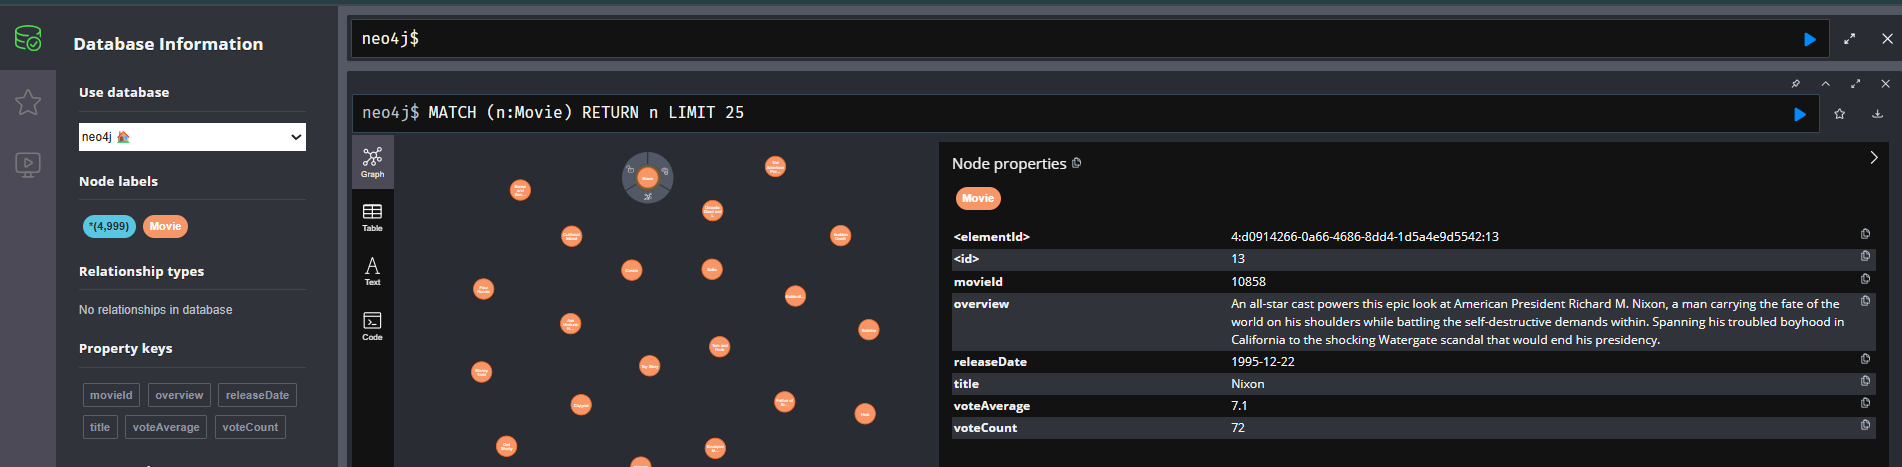

### 장르 노드 및 관계 생성

In [79]:
# ============================================
# 장르 노드 및 관계 생성
# ============================================
def create_genres(session, movies_df):
    """장르 노드와 영화-장르 관계 생성"""
    query = """
    // UNWIND: 영화-장르 쌍 배열을 개별 행으로 분해
    UNWIND $movie_genres AS mg
    
    // MATCH: 이미 생성된 Movie 노드를 movieId로 찾기
    MATCH (m:Movie {movieId: mg.movieId})
    
    // MERGE: 장르 이름으로 Genre 노드 찾거나 생성
    // 동일한 장르는 하나의 노드로만 존재 (중복 방지)
    MERGE (g:Genre {name: mg.genre})
    
    // MERGE: Movie와 Genre 사이에 HAS_GENRE 관계 생성
    // 이미 관계가 있으면 생성하지 않음 (중복 방지)
    MERGE (m)-[:HAS_GENRE]->(g)
    """
    
    movie_genres = []
    for _, row in movies_df.iterrows():
        movie_id = str(row['id'])
        genres = row['genres_list']
        for genre in genres:
            movie_genres.append({
                'movieId': movie_id,
                'genre': genre
            })
    
    if movie_genres:
        session.run(query, movie_genres=movie_genres)
        print(f"장르 관계 {len(movie_genres)}개 생성 완료!")


In [80]:
with driver.session() as session:
    create_genres(session, movies_df)


장르 관계 12008개 생성 완료!


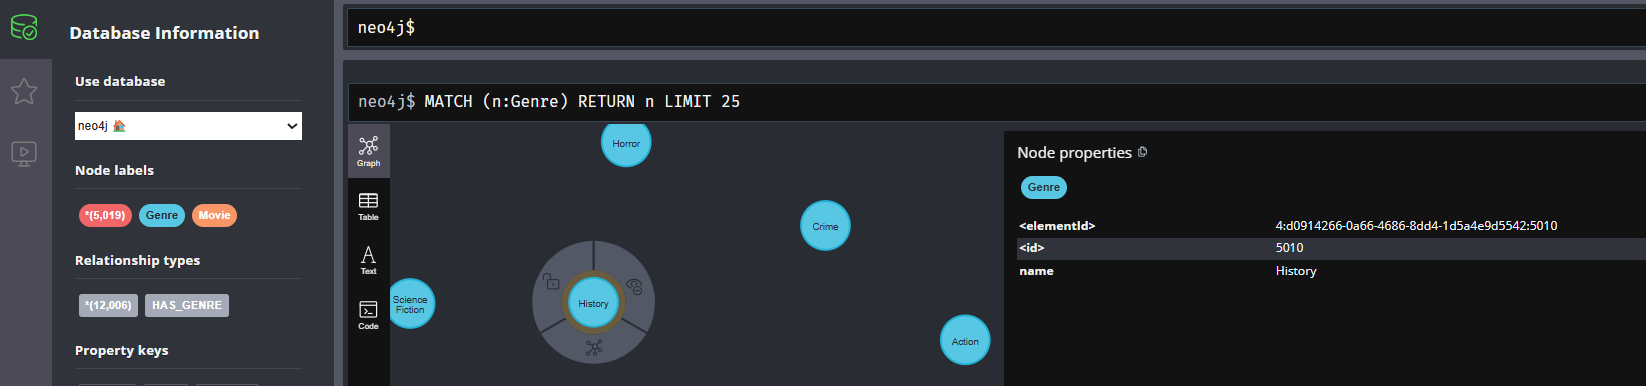

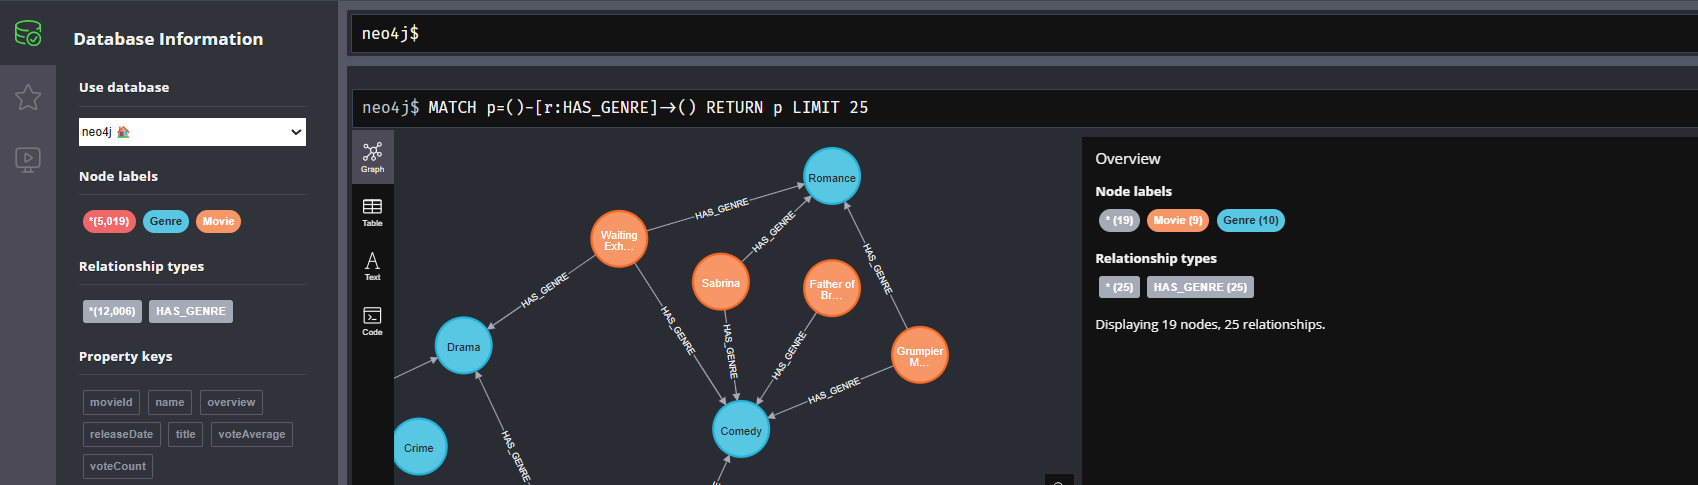

### 사용자 노드 및 평점 관계 생성

In [81]:
# ============================================
# 사용자 노드 및 평점 관계 생성
# ============================================
def create_ratings(session, ratings_df):
    """사용자 노드와 평점 관계 생성"""
    # 배치 처리로 성능 향상
    batch_size = 1000
    total_ratings = len(ratings_df)
    
    query = """
    // UNWIND: 평점 배열을 개별 행으로 분해
    UNWIND $ratings AS rating
    
    // MERGE: userId로 User 노드 찾거나 생성
    // 동일한 사용자는 하나의 노드로만 존재
    MERGE (u:User {userId: rating.userId})
    
    // MERGE: movieId로 Movie 노드 찾거나 생성
    // 영화 노드는 이미 생성되어 있어야 함
    MERGE (m:Movie {movieId: rating.movieId})
    
    // MERGE: User와 Movie 사이에 RATED 관계 생성
    // 사용자-영화 간 평점 관계 (중복 방지)
    MERGE (u)-[r:RATED]->(m)
    
    // SET: 평점 관계의 속성 설정
    // rating: 평점 (1.0 ~ 5.0)
    // timestamp: 평점을 매긴 시간
    SET r.rating = rating.rating,
        r.timestamp = rating.timestamp
    """
    
    processed = 0
    for i in range(0, total_ratings, batch_size):
        batch = ratings_df.iloc[i:i+batch_size]
        ratings = []
        for _, row in batch.iterrows():
            ratings.append({
                'userId': str(int(row['userId'])),
                'movieId': str(int(row['movieId'])),
                'rating': float(row['rating']),
                'timestamp': int(row['timestamp'])
            })
        
        session.run(query, ratings=ratings)
        processed += len(ratings)
        if (i // batch_size + 1) % 10 == 0:
            print(f"  진행 중... {processed}/{total_ratings}")
    
    print(f"평점 관계 {processed}개 생성 완료!")


In [82]:
with driver.session() as session:
    create_ratings(session, ratings_df)


  진행 중... 10000/19269
  진행 중... 19269/19269
평점 관계 19269개 생성 완료!


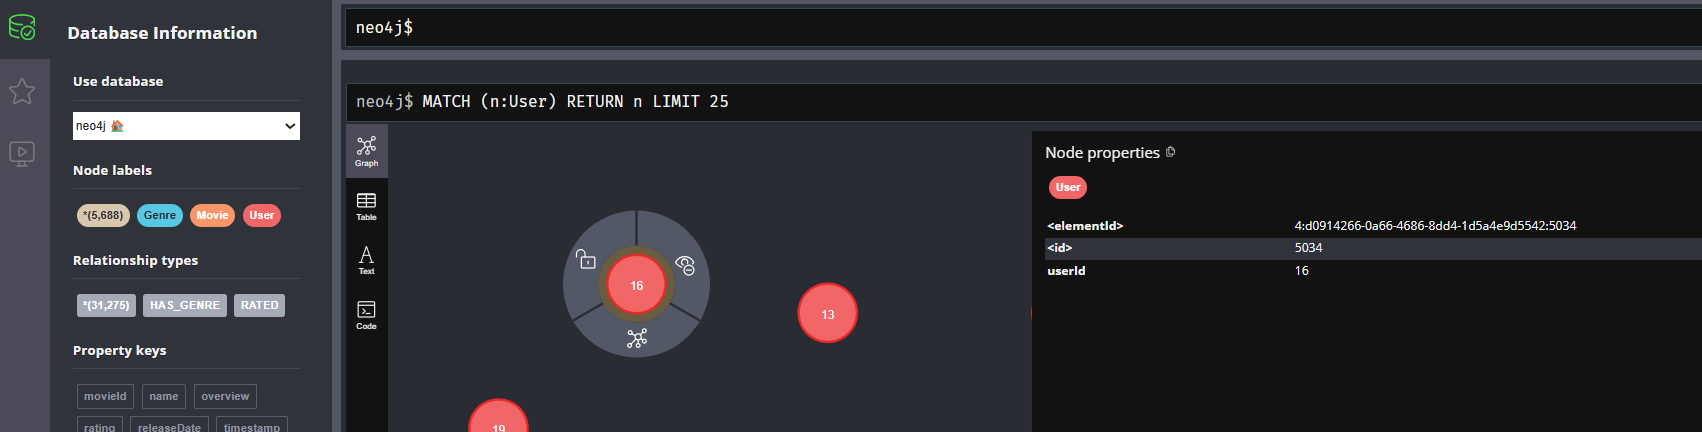

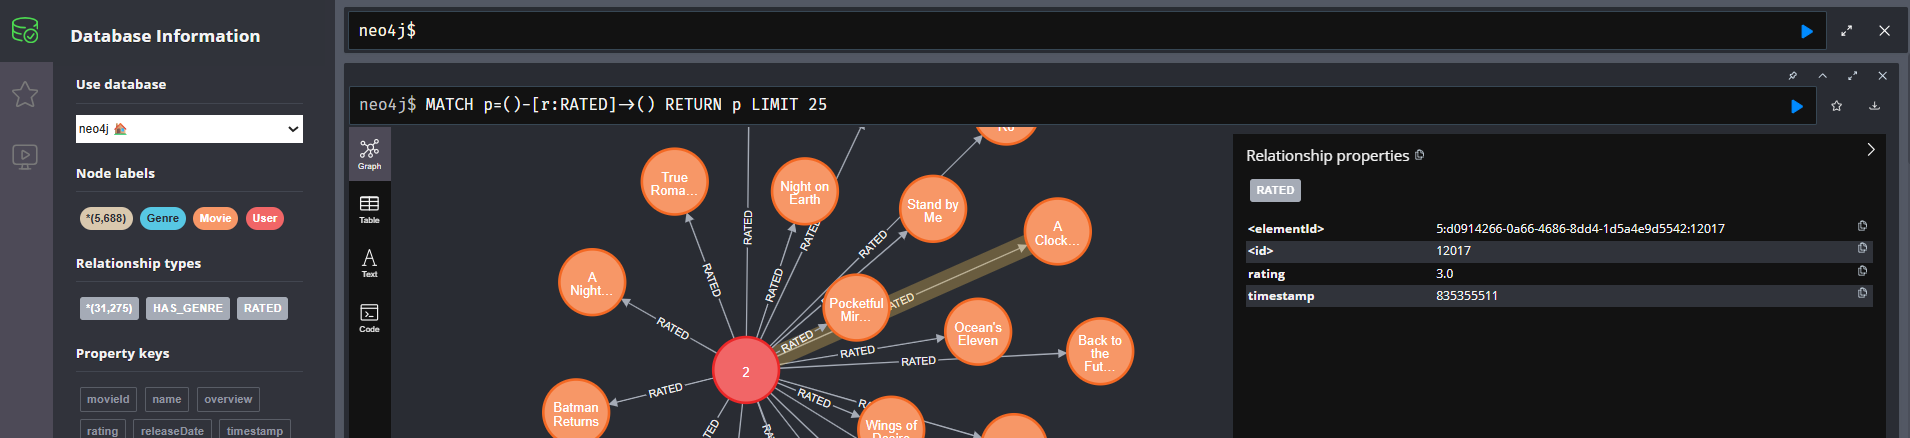

### 그래프 통계 확인

In [83]:
with driver.session() as session:
    query = """
    // MATCH: 모든 노드 선택
    MATCH (n)
    
    // RETURN: 노드의 레이블과 개수 반환
    // labels(n)[0]: 노드의 첫 번째 레이블 추출 (Genre, Movie, User 등)
    // count(n): 각 레이블별 노드 개수 집계
    RETURN labels(n)[0] AS label, count(n) AS count
    
    // ORDER BY: 레이블 이름으로 정렬 (알파벳 순)
    ORDER BY label
    """
    result = session.run(query)

    print("=== 노드 통계 ===")
    for record in result:
        print(f"  {record['label']}: {record['count']}개")

=== 노드 통계 ===
  Genre: 20개
  Movie: 4999개
  User: 669개


In [85]:
with driver.session() as session:
    query = """
    // MATCH: 모든 관계 선택
    // ()-[r]->(): 모든 노드 간의 방향성 관계 매칭
    MATCH ()-[r]->()
    
    // RETURN: 관계 타입과 개수 반환
    // type(r): 관계의 타입 추출 (HAS_GENRE, RATED 등)
    // count(r): 각 관계 타입별 개수 집계
    RETURN type(r) AS type, count(r) AS count
    
    // ORDER BY: 관계 타입으로 정렬 (알파벳 순)
    ORDER BY type
    """
    result = session.run(query)
    
    print("\n=== 관계 통계 ===")
    for record in result:
        print(f"  {record['type']}: {record['count']}개")



=== 관계 통계 ===
  HAS_GENRE: 12006개
  RATED: 19269개


## 6. GDS 그래프 프로젝션

GDS 알고리즘을 실행하기 전에 Neo4j 데이터를 GDS 형식으로 프로젝션해야 합니다.

### 그래프 프로젝션이란?
- Neo4j의 실제 데이터를 메모리 내 그래프 구조로 변환
- 알고리즘 실행 속도 향상
- 필요한 노드와 관계만 선택하여 프로젝션 가능
- GDS는 숫자 타입 속성만 프로젝션할 수 있음 


### 영화-사용자 평점 그래프 프로젝션

In [ ]:
# ============================================
# 영화-사용자 평점 그래프 프로젝션
# ============================================
# 이 그래프는 사용자와 영화 간의 평점 관계를 나타냅니다.
# 추천 시스템의 핵심 그래프입니다.

G_movies_users, result = gds.graph.project(
    "movies-users-graph",  # 생성될 GDS In-Memory 그래프의 이름
    ["Movie", "User"],     # 노드 레이블
    "RATED",                # 관계 타입
    nodeProperties=["voteAverage"],  # 노드 속성 (선택사항: Boolean, String 사용불가)
    relationshipProperties=["rating"]         # 관계 속성 (선택사항: Boolean, String 사용불가)
)

print(f"그래프 프로젝션 완료!")


그래프 프로젝션 완료!


In [87]:
print(f"  노드 수: {G_movies_users.node_count()}")
print(f"  관계 수: {G_movies_users.relationship_count()}")
print(f"  메모리 사용량: {G_movies_users.memory_usage()}")

  노드 수: 5668
  관계 수: 19269
  메모리 사용량: 4896 KiB


### 영화-장르 그래프 프로젝션

In [ ]:
# ============================================
# 영화-장르 그래프 프로젝션
# ============================================
# 이 그래프는 영화와 장르 간의 관계를 나타냅니다.
# 유사 영화 찾기에 활용됩니다.

G_movies_genres, result = gds.graph.project(
    "movies-genres-graph",      # 생성될 GDS In-Memory 그래프의 이름
    ["Movie", "Genre"],         # 노드 레이블
    "HAS_GENRE"                 # 관계 타입
)

print(f"그래프 프로젝션 완료!")


그래프 프로젝션 완료!


In [89]:
print(f"  노드 수: {G_movies_genres.node_count()}")
print(f"  관계 수: {G_movies_genres.relationship_count()}")
print(f"  메모리 사용량: {G_movies_genres.memory_usage()}")

  노드 수: 5019
  관계 수: 12006
  메모리 사용량: 1446 KiB


## 7. 영화 추천 시스템 구현


### 7.1 PageRank로 인기 영화 추천

- PageRank는 구글의 검색 알고리즘에 사용되는 기법으로, 많은 사용자에게 높은 평점을 받은 영화 추천
- 콜드 스타트 문제 해결 (신규 사용자에게 유용)


#### PageRank를 실행하여 각 영화의 중요도 계산

In [ ]:
# ============================================
# PageRank 실행
# ============================================
# PageRank를 실행하여 각 영화의 중요도 계산
pagerank_result = gds.pageRank.mutate(
    G_movies_users,                         # 분석할 In-Memory 그래프
    mutateProperty="pagerank",              # 계산된 PageRank 값을 저장할 노드 속성 이름
    relationshipWeightProperty="rating",    # RATED 관계의 rating 값을 가중치로 사용
    dampingFactor=0.85,                     # PageRank 알고리즘에서 일반적으로 사용하는 감쇄 계수
    maxIterations=20                        # 최대 반복 횟수 (수렴 조건)
)

print(f"PageRank 실행 완료!")
print(f"  처리 시간: {pagerank_result['computeMillis']} ms")
print(f"  노드 수: {pagerank_result['nodePropertiesWritten']}")

PageRank 실행 완료!
  처리 시간: 117 ms
  노드 수: 5668


#### 결과를 Neo4j에 저장

In [ ]:
# 결과를 Neo4j에 저장
gds.graph.nodeProperties.write(
    G_movies_users,                     # 대상 GDS In-Memory 그래프
    node_properties=["pagerank"],       # DB에 기록할 속성 이름
    node_labels=["Movie"]               # 어떤 라벨의 노드에 기록할지 지정 (Movie 노드만 저장)
)
print("PageRank 결과를 Neo4j에 저장 완료!")


PageRank 결과를 Neo4j에 저장 완료!


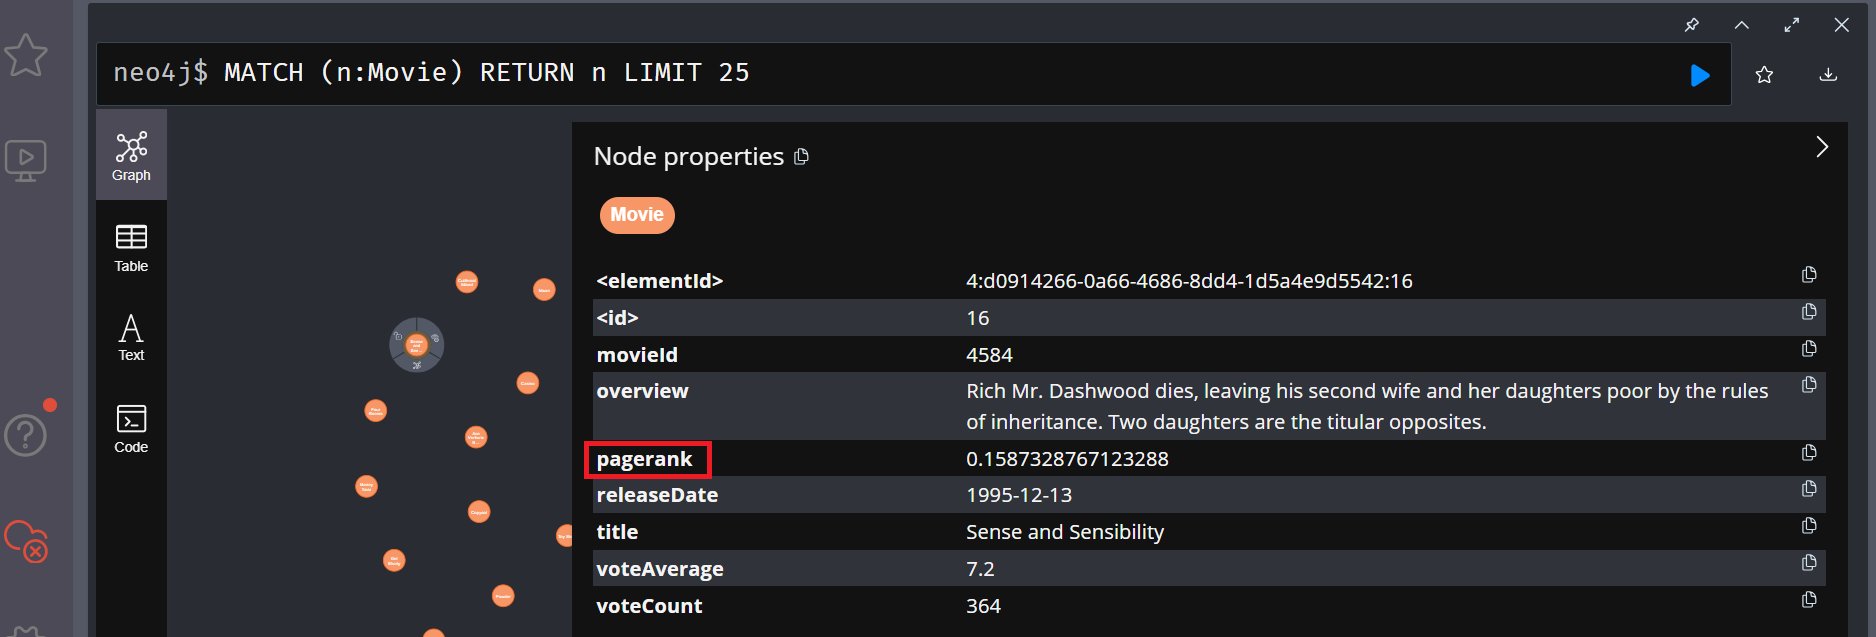

#### 인기 영화 Top 10 조회

In [92]:
# ============================================
# 인기 영화 Top 10 조회
# ============================================
def get_popular_movies(top_n=10):
    """PageRank 기반 인기 영화 조회"""
    query = """
    // MATCH: 모든 Movie 노드 선택
    MATCH (m:Movie)
    
    // WHERE: pagerank 속성이 있는 영화만 필터링
    // PageRank 알고리즘 실행 후 생성된 속성
    WHERE m.pagerank IS NOT NULL
    
    // RETURN: 영화 정보 반환
    // title: 영화 제목
    // pagerank: PageRank 점수 (인기도 지표)
    // voteAverage: 평균 평점
    // voteCount: 평점 개수
    RETURN m.title AS title, 
           m.pagerank AS score,
           m.voteAverage AS voteAverage,
           m.voteCount AS voteCount
    
    // ORDER BY: PageRank 점수 내림차순 정렬 (가장 인기 있는 영화 먼저)
    ORDER BY m.pagerank DESC
    
    // LIMIT: 상위 N개만 반환
    LIMIT $top_n
    """
    with driver.session() as session:
        result = session.run(query, top_n=top_n)
        movies = []
        for record in result:
            movies.append({
                'title': record['title'],
                'pagerank_score': record['score'],
                'vote_average': record['voteAverage'],
                'vote_count': record['voteCount']
            })
    return pd.DataFrame(movies)
    

In [93]:
# 인기 영화 조회
popular_movies = get_popular_movies(10)
print("=== PageRank 기반 인기 영화 Top 10 ===")
popular_movies.head()


=== PageRank 기반 인기 영화 Top 10 ===


,title,pagerank_score,vote_average,vote_count
0,The Million Dollar Hotel,3.447363,5.9,76
1,The 39 Steps,2.620785,7.4,217
2,Solaris,2.579497,7.7,364
3,Once Were Warriors,2.021206,7.6,106
4,Sleepless in Seattle,1.806879,6.5,630


### 7.2 Node Similarity로 유사 영화 찾기 (장르 기반)

- 장르가 유사한 영화 찾기
- 컨텐츠 기반 필터링


#### Jaccard Similarity를 사용하여 영화 간 유사도 계산

In [ ]:
# ============================================
# Node Similarity (장르 기반) 실행
# G_movies_genres 그래프는 Movie 노드와 Genre 노드 간의 관계를 포함하고 있으며,
# Jaccard Similarity를 통해 두 영화가 공유하는 장르가 많을수록 높은 유사도를 부여한다.
# ============================================
similarity_result = gds.nodeSimilarity.write(
    G_movies_genres,                        # 분석에 사용할 In-Memory 그래프
    writeRelationshipType="SIMILAR_TO",     # 유사한 영화 간 생성할 관계 이름
    writeProperty="similarity",             # 관계에 저장할 유사도 속성명
    similarityCutoff=0.1,                   # 유사도 0.1 이상만 DB에 기록 (노이즈 필터링)
    topK=10                                 # 각 영화 기준 상위 10개의 유사한 영화만 저장
)

print(f"Node Similarity 실행 완료!")
print(f"  처리 시간: {similarity_result['computeMillis']} ms")
print(f"  생성된 관계: {similarity_result['relationshipsWritten']}개")
print(f"  평균 유사도: {similarity_result['similarityDistribution']['mean']:.4f}")


Node Similarity 실행 완료!
  처리 시간: 406 ms
  생성된 관계: 48930개
  평균 유사도: 0.9498


#### 특정 영화와 유사한 영화 추천

In [ ]:
# ============================================
# 특정 영화와 유사한 영화 추천
# ============================================
def get_similar_movies(movie_title, top_n=5):
    """특정 영화와 유사한 영화 찾기 (장르 기반)"""
    query = """
    // MATCH: SIMILAR_TO 관계로 연결된 영화 쌍 찾기
    // m1: 원본 영화 (사용자가 검색한 영화)
    // s: SIMILAR_TO 관계 (유사도 정보 포함)
    // m2: 유사한 영화 (추천할 영화)
    MATCH (m1:Movie)-[s:SIMILAR_TO]->(m2:Movie)
    
    // WHERE: 제목이 검색어를 포함하는 영화 필터링
    // CONTAINS: 부분 문자열 매칭 (대소문자 구분)
    WHERE m1.title CONTAINS $title
    
    // RETURN: 원본 영화, 유사 영화, 유사도 점수 반환
    // similarity: Jaccard 유사도 (0~1, 1에 가까울수록 유사)
    RETURN m1.title AS source_movie,
           m2.title AS similar_movie,
           s.similarity AS similarity_score
    
    // ORDER BY: 유사도 점수 내림차순 정렬 (가장 유사한 영화 먼저)
    ORDER BY s.similarity DESC
    
    // LIMIT: 상위 N개만 반환
    LIMIT $top_n
    """
    with driver.session() as session:
        result = session.run(query, title=movie_title, top_n=top_n)
        movies = []
        for record in result:
            movies.append({
                'source': record['source_movie'],
                'recommendation': record['similar_movie'],
                'similarity': round(record['similarity_score'], 4)
            })
    return pd.DataFrame(movies)
    

#### 예제: "Toy Story"와 유사한 영화

In [52]:
# 예제: "Toy Story"와 유사한 영화
print("=== Toy Story와 유사한 영화 (장르 기반) ===")
similar = get_similar_movies("Toy Story", 5)
similar.head()


=== Toy Story와 유사한 영화 (장르 기반) ===


,source,recommendation,similarity
0,Toy Story,"Monsters, Inc.",1.0
1,Toy Story,Chicken Run,1.0
2,Toy Story,Creature Comforts,1.0
3,Toy Story,The Wrong Trousers,1.0
4,Toy Story,Doug's 1st Movie,1.0


### 7.3 Louvain Community Detection으로 영화 클러스터링
> Louvain 알고리즘은 커뮤니티(클러스터)를 찾는 알고리즘입니다.

- 비슷한 평가 패턴을 가진 영화 그룹화
- 사용자 취향에 맞는 영화 클러스터 발견


#### Louvain Community Detection 실행

In [ ]:
# ============================================
# Louvain Community Detection 실행
# Louvain 알고리즘은 그래프에서 커뮤니티(군집)를 찾는 대표적인 알고리즘이다.
# 사용자-영화 평점 그래프(G_movies_users)를 기반으로 사용자가 비슷한 영화에
# 평점을 남기는 패턴을 분석하여 커뮤니티를 식별한다.
# ============================================
louvain_result = gds.louvain.write(
    G_movies_users,                         # 분석할 GDS In-Memory 그래프
    writeProperty="community",              # 커뮤니티 ID를 저장할 속성명
    relationshipWeightProperty="rating",    # 평점을 엣지 가중치로 사용
    includeIntermediateCommunities=False    # 중간 단계 커뮤니티 저장 여부 (False = 최종 결과만)
)

print(f"Louvain Community Detection 완료!")
print(f"  처리 시간: {louvain_result['computeMillis']} ms")
print(f"  발견된 커뮤니티 수: {louvain_result['communityCount']}")
print(f"  모듈성 점수: {louvain_result['modularity']:.4f}")


 Louvain:   0%|          | 0/100 [00:00<?, ?%/s]

Louvain Community Detection 완료!
  처리 시간: 2266 ms
  발견된 커뮤니티 수: 4704
  모듈성 점수: 0.0304


#### 커뮤니티별 영화 분석

In [ ]:
# ============================================
# 커뮤니티별 영화 분석
# ============================================
def analyze_communities(top_communities=5, movies_per_community=5):
    """각 커뮤니티의 대표 영화 분석"""
    query = """
    // MATCH: 모든 Movie 노드 선택
    MATCH (m:Movie)
    
    // WHERE: community 속성이 있는 영화만 필터링
    // Louvain 알고리즘으로 생성된 커뮤니티 ID
    WHERE m.community IS NOT NULL
    
    // WITH: 커뮤니티별로 그룹화하고 영화 개수 집계
    // community: 커뮤니티 ID
    // count(*): 각 커뮤니티의 영화 수
    WITH m.community AS community, count(*) AS movie_count
    
    // ORDER BY: 영화 수 내림차순 정렬 (큰 커뮤니티 먼저)
    ORDER BY movie_count DESC
    
    // LIMIT: 상위 N개 커뮤니티만 선택
    LIMIT $top_communities
    
    // RETURN: 커뮤니티 ID와 영화 수 반환
    RETURN community, movie_count
    """
    
    with driver.session() as session:
        result = session.run(query, top_communities=top_communities)
        communities = []
        
        for record in result:
            comm_id = record['community']
            movie_count = record['movie_count']
            
            # 각 커뮤니티의 대표 영화들 조회
            movies_query = """
            // MATCH: 특정 커뮤니티의 영화들 선택
            MATCH (m:Movie)
            
            // WHERE: 해당 커뮤니티 ID로 필터링
            WHERE m.community = $community
            
            // RETURN: 영화 제목, 평점, 인기도 반환
            RETURN m.title AS title, 
                   m.voteAverage AS rating,
                   m.pagerank AS popularity
            
            // ORDER BY: PageRank 내림차순 정렬 (인기 있는 영화 먼저)
            ORDER BY m.pagerank DESC
            
            // LIMIT: 상위 N개만 반환
            LIMIT $limit
            """
            movies_result = session.run(
                movies_query, 
                community=comm_id, 
                limit=movies_per_community
            )
            
            movies = [r['title'] for r in movies_result]
            
            communities.append({
                'community_id': comm_id,
                'movie_count': movie_count,
                'top_movies': ', '.join(movies[:3])  # 상위 3개만 표시
            })
        
        return pd.DataFrame(communities)


In [55]:
# 커뮤니티 분석
print("=== 영화 커뮤니티 분석 (Top 5) ===")
communities = analyze_communities(5, 5)
communities.head()

=== 영화 커뮤니티 분석 (Top 5) ===


,community_id,movie_count,top_movies
0,1851,50,"The Million Dollar Hotel, Once Were Warriors, ..."
1,1300,49,"Arlington Road, Psycho, Donnie Darko"
2,385,39,"The 39 Steps, Solaris, Sleepless in Seattle"
3,1215,36,"Rope, The Man with the Golden Arm, Beetlejuice"
4,875,27,"Batman Returns, Ariel, Cool Hand Luke"


### 7.4 사용자 기반 협업 필터링 추천
> 특정 사용자가 좋아할 만한 영화를 추천합니다.

- 같은 커뮤니티 내 인기 영화 추천
- 사용자 행동 패턴 기반 추천


#### 사용자 기반 협업 필터링 추천

In [ ]:
# ============================================
# 사용자 기반 협업 필터링 추천
# ============================================
def recommend_for_user(user_id, top_n=10):
    """특정 사용자를 위한 영화 추천"""
    
    # 1. 사용자가 본 영화와 같은 커뮤니티의 영화 추천
    query = """
    // 1단계: 사용자가 평점을 매긴 영화들을 찾고 평균 평점 계산
    // MATCH: userId로 User 노드 찾고 RATED 관계로 Movie 연결
    MATCH (u:User {userId: $userId})-[r:RATED]->(m:Movie)
    
    // WITH: 사용자, 시청한 영화 리스트, 평균 평점을 다음 단계로 전달
    // collect(m): 사용자가 본 모든 영화를 배열로 수집
    // avg(r.rating): 사용자의 평균 평점 계산
    WITH u, collect(m) AS watched_movies, 
         avg(r.rating) AS avg_user_rating
    
    // 2단계: 사용자가 본 영화들의 커뮤니티 찾기
    // MATCH: 사용자가 평점을 매긴 영화 중 커뮤니티가 있는 영화들
    MATCH (watched:Movie)<-[:RATED]-(u)
    WHERE watched.community IS NOT NULL
    
    // WITH: 사용자가 선호하는 커뮤니티 ID들 수집
    // collect(DISTINCT watched.community): 중복 제거한 커뮤니티 ID 배열
    WITH u, watched_movies, avg_user_rating, 
         collect(DISTINCT watched.community) AS user_communities
    
    // 3단계: 같은 커뮤니티의 인기 영화 중 아직 안 본 영화 찾기
    // MATCH: 추천할 Movie 노드 선택
    MATCH (rec:Movie)
    WHERE rec.community IN user_communities  // 사용자가 선호하는 커뮤니티
      AND NOT rec IN watched_movies           // 아직 안 본 영화만
      AND rec.pagerank IS NOT NULL            // PageRank 점수가 있는 영화만
    
    // RETURN: 추천 영화 정보 반환
    RETURN rec.title AS title,
           rec.pagerank AS popularity,        // 인기도
           rec.voteAverage AS rating,         // 평균 평점
           rec.community AS community         // 커뮤니티 ID
    
    // ORDER BY: PageRank 내림차순 정렬 (인기 있는 영화 먼저)
    ORDER BY rec.pagerank DESC
    
    // LIMIT: 상위 N개만 반환
    LIMIT $top_n
    """
    
    with driver.session() as session:
        result = session.run(query, userId=user_id, top_n=top_n)
        recommendations = []
        for record in result:
            recommendations.append({
                'title': record['title'],
                'popularity_score': round(record['popularity'], 6),
                'avg_rating': record['rating'],
                'community': record['community']
            })
    
    return pd.DataFrame(recommendations)


#### 예제: 사용자 1번을 위한 추천

In [57]:
# 예제: 사용자 1번을 위한 추천
print("=== 사용자 1번을 위한 추천 영화 ===")
user_recs = recommend_for_user("1", 10)
user_recs.head()


=== 사용자 1번을 위한 추천 영화 ===


,title,popularity_score,avg_rating,community
0,Arlington Road,0.930092,7.0,1300
1,Scarface,0.815619,8.0,1854
2,Psycho,0.600275,8.3,1300
3,Donnie Darko,0.583615,7.7,1300
4,Light of Day,0.549569,5.4,1300


### 7.5 종합 추천 시스템 (Hybrid)
> 여러 추천 방법을 결합한 하이브리드 추천 시스템입니다.

- 장르 유사도
- 커뮤니티 기반
- 인기도 (PageRank)
를 모두 고려하여 점수를 계산합니다.


#### 하이브리드 추천 시스템

In [ ]:
# ============================================
# 하이브리드 추천 시스템
# ============================================
def hybrid_recommend(movie_title=None, user_id=None, top_n=10):
    """
    하이브리드 추천 시스템
    - movie_title: 영화 제목으로 유사 영화 추천
    - user_id: 사용자 ID로 개인화 추천
    """
    
    if movie_title:
        # 영화 기반 추천 (컨텐츠 + 협업 필터링)
        query = """
        // 1단계: 유사한 영화 찾기 (장르 기반)
        // MATCH: SIMILAR_TO 관계로 연결된 영화 쌍 찾기
        MATCH (m1:Movie)-[s:SIMILAR_TO]->(m2:Movie)
        
        // WHERE: 제목이 검색어를 포함하는 영화 필터링
        WHERE m1.title CONTAINS $title
        
        // WITH: 장르 유사도를 다음 단계로 전달
        WITH m1, m2, s.similarity AS genre_similarity
        
        // 2단계: 커뮤니티 보너스 점수 계산
        // CASE: 같은 커뮤니티에 속한 영화면 1.5, 아니면 1.0
        // COALESCE: pagerank가 null이면 0으로 대체
        WITH m2, 
             genre_similarity,
             CASE WHEN m1.community = m2.community THEN 1.5 ELSE 1.0 END AS community_bonus,
             COALESCE(m2.pagerank, 0) AS popularity
        
        // 3단계: 최종 하이브리드 점수 계산 (가중 평균)
        // 장르 유사도 40% + 인기도 30% + 커뮤니티 보너스 30%
        WITH m2,
             (genre_similarity * 0.4 + 
              popularity * 1000 * 0.3 + 
              community_bonus * 0.3) AS hybrid_score,
             genre_similarity,
             popularity
        
        // RETURN: 추천 영화와 각 점수 반환
        RETURN m2.title AS title,
               hybrid_score AS score,          // 최종 하이브리드 점수
               genre_similarity,                // 장르 유사도
               popularity,                      // PageRank 인기도
               m2.voteAverage AS rating        // 평균 평점
        
        // ORDER BY: 하이브리드 점수 내림차순 정렬
        ORDER BY hybrid_score DESC
        
        // LIMIT: 상위 N개만 반환
        LIMIT $top_n
        """
        
        with driver.session() as session:
            result = session.run(query, title=movie_title, top_n=top_n)
            recommendations = []
            for record in result:
                recommendations.append({
                    'title': record['title'],
                    'hybrid_score': round(record['score'], 4),
                    'genre_similarity': round(record['genre_similarity'], 4),
                    'popularity': round(record['popularity'], 6),
                    'rating': record['rating']
                })
        
        return pd.DataFrame(recommendations)
    
    elif user_id:
        # 사용자 기반 추천
        query = """
        // 1단계: 사용자가 본 영화들과 평균 평점 계산
        // MATCH: userId로 User 찾고 RATED 관계로 Movie 연결
        MATCH (u:User {userId: $userId})-[r:RATED]->(m:Movie)
        
        // WITH: 시청한 영화 리스트와 평균 평점을 다음 단계로 전달
        WITH u, collect(m) AS watched_movies, avg(r.rating) AS user_avg_rating
        
        // 2단계: 사용자가 좋아한 영화들 찾기 (평점 >= 평균)
        // MATCH: 사용자의 평점 관계 다시 매칭
        MATCH (u)-[r2:RATED]->(liked:Movie)
        
        // WHERE: 평균 이상의 평점을 받은 영화만 선택
        WHERE r2.rating >= user_avg_rating
        
        // WITH: 좋아한 영화 리스트 수집
        WITH u, watched_movies, collect(DISTINCT liked) AS liked_movies
        
        // 3단계: 좋아한 영화와 유사한 영화 찾기
        // MATCH: 좋아한 영화와 SIMILAR_TO 관계로 연결된 영화들
        MATCH (liked)-[s:SIMILAR_TO]->(rec:Movie)
        WHERE liked IN liked_movies          // 좋아한 영화들 중
          AND NOT rec IN watched_movies      // 아직 안 본 영화만
        
        // WITH: 유사도 평균과 인기도 계산
        // avg(s.similarity): 여러 좋아한 영화들과의 평균 유사도
        WITH rec, 
             avg(s.similarity) AS avg_similarity,
             COALESCE(rec.pagerank, 0) AS popularity,
             rec.voteAverage AS rating
        
        // 4단계: 최종 하이브리드 점수 계산
        // 유사도 50% + 인기도 50%
        WITH rec,
             (avg_similarity * 0.5 + popularity * 1000 * 0.5) AS hybrid_score,
             avg_similarity,
             popularity,
             rating
        
        // RETURN: 추천 영화와 각 점수 반환
        RETURN rec.title AS title,
               hybrid_score AS score,          // 최종 하이브리드 점수
               avg_similarity,                 // 평균 유사도
               popularity,                     // PageRank 인기도
               rating                          // 평균 평점
        
        // ORDER BY: 하이브리드 점수 내림차순 정렬
        ORDER BY hybrid_score DESC
        
        // LIMIT: 상위 N개만 반환
        LIMIT $top_n
        """
        
        with driver.session() as session:
            result = session.run(query, userId=user_id, top_n=top_n)
            recommendations = []
            for record in result:
                recommendations.append({
                    'title': record['title'],
                    'hybrid_score': round(record['score'], 4),
                    'avg_similarity': round(record['avg_similarity'], 4),
                    'popularity': round(record['popularity'], 6),
                    'rating': record['rating']
                })
        
        return pd.DataFrame(recommendations)
    
    else:
        print("movie_title 또는 user_id 중 하나를 제공해야 합니다.")
        return pd.DataFrame()



#### 영화 기반 추천 예제

In [59]:
print("=== 하이브리드 추천: 'Jumanji'와 유사한 영화 ===")
movie_recs = hybrid_recommend(movie_title="Jumanji", top_n=5)
movie_recs.head() 

=== 하이브리드 추천: 'Jumanji'와 유사한 영화 ===


,title,hybrid_score,genre_similarity,popularity,rating
0,Harry Potter and the Philosopher's Stone,98.9287,1.0,0.327429,7.5
1,The Wizard of Oz,48.7707,1.0,0.160236,7.4
2,Return to Oz,45.7000,1.0,0.150000,6.6
3,Labyrinth,45.7000,1.0,0.150000,7.1
4,The Indian in the Cupboard,45.7000,1.0,0.150000,5.9


#### 사용자 기반 추천 예제

In [60]:
print("=== 하이브리드 추천: 사용자 1번을 위한 영화 ===")
user_recs = hybrid_recommend(user_id="1", top_n=5)
user_recs.head()

=== 하이브리드 추천: 사용자 1번을 위한 영화 ===


,title,hybrid_score,avg_similarity,popularity,rating
0,French Twist,78.5859,1.0,0.156172,6.0
1,Flirting with Disaster,76.3044,1.0,0.151609,6.3
2,Grumpier Old Men,75.5000,1.0,0.150000,6.5
3,Sabrina,75.5000,1.0,0.150000,6.2
4,Mighty Aphrodite,75.5000,1.0,0.150000,6.7


## 8. 정리 및 리소스 해제


#### 그래프 프로젝션 삭

In [61]:
# ============================================
# 그래프 프로젝션 삭제 (선택사항)
# ============================================
# 메모리를 확보하려면 GDS 그래프 프로젝션을 삭제할 수 있습니다.
# 주의: 삭제 후에는 알고리즘을 다시 실행할 수 없습니다.
G_movies_users.drop()
G_movies_genres.drop()
print("그래프 프로젝션 삭제 완료!")

그래프 프로젝션 삭제 완료!


#### 기존 데이터 삭제 (선택사항)

In [ ]:
# ============================================
# 기존 데이터 삭제 (선택사항)
# ============================================
# 주의: 모든 데이터가 삭제됩니다!
with driver.session() as session:
    # MATCH (n): 모든 노드 선택
    # DETACH DELETE n: 노드와 연결된 모든 관계를 먼저 삭제한 후 노드 삭제
    session.run("MATCH (n) DETACH DELETE n")
    print("기존 데이터 삭제 완료!")

기존 데이터 삭제 완료!


#### Neo4j 연결 종료

In [63]:
# 연결 종료
driver.close()
print("Neo4j 연결 종료!")


Neo4j 연결 종료!
